In [1]:
!pip install polars

import polars as pl
import os
import random
import sys
import cv2
from tqdm import tqdm
import json
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
import cv2
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import pandas as pd
from PIL import Image
import os
from torchvision import transforms
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import random


In [2]:
import os
os.chdir('/workspace')

In [3]:
BASE_PATH = 'vindr_mammogram'
IMG_DIR = os.path.join(BASE_PATH, 'mammo_processed_cropped') 
df=pd.read_csv(f'{IMG_DIR}/mammo_processed_cropped.csv')
df = df.drop_duplicates(subset=['study_id', 'image_id'])
df["processed_path"] = (
    df["processed_path"]
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False))

/tmp/ipykernel_130154/2858854542.py:3: DtypeWarning: Columns (0: finding_birads) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(f'{IMG_DIR}/mammo_processed_cropped.csv')


In [4]:
df.head()

,study_id,series_id,image_id,laterality,view_position,height,width,breast_birads,breast_density,finding_categories,...,adjusted_ymin,adjusted_xmax,adjusted_ymax,roi_width,roi_height,processed_path,roi_xmin,roi_ymin,roi_xmax,roi_ymax
0,48575a27b7c992427041a82fa750d3fa,26de4993fa6b8ae50a91c8baf49b92b0,4e3a578fe535ea4f5258d3f7f4419db8,R,CC,3518,2800,BI-RADS 4,DENSITY C,['Mass'],...,1280.640015,720.979980,1401.750000,963,1971,vindr_mammogram/mammo_processed_cropped/48575a...,518.139893,1280.640015,645.979980,1401.750000
1,48575a27b7c992427041a82fa750d3fa,26de4993fa6b8ae50a91c8baf49b92b0,dac39351b0f3a8c670b7f8dc88029364,R,MLO,3518,2800,BI-RADS 4,DENSITY C,['Mass'],...,1240.609985,771.800049,1354.040039,1049,2229,vindr_mammogram/mammo_processed_cropped/48575a...,635.679932,1240.609985,750.800049,1354.040039
2,75e8e48933289d70b407379a564f8594,853b70e7e6f39133497909d9ca4c756d,c83f780904f25eacb44e9030f32c66e1,R,CC,3518,2800,BI-RADS 3,DENSITY C,['Global Asymmetry'],...,638.510010,816.439941,1656.260010,834,1953,vindr_mammogram/mammo_processed_cropped/75e8e4...,313.179932,638.510010,738.439941,1656.260010
3,75e8e48933289d70b407379a564f8594,853b70e7e6f39133497909d9ca4c756d,893528bc38a0362928a89364f1b692fd,R,MLO,3518,2800,BI-RADS 3,DENSITY C,['Global Asymmetry'],...,1443.640015,906.760010,2193.810059,1061,2372,vindr_mammogram/mammo_processed_cropped/75e8e4...,215.270020,1443.640015,850.760010,2193.810059
4,c3487424fee1bdd4515b72dc3fd69813,77619c914263eae44e9099f1ce07192c,318264c881bf12f2c1efe5f93920cc37,R,CC,3518,2800,BI-RADS 4,DENSITY C,['Architectural Distortion'],...,1533.410034,728.699951,1713.159912,1140,2115,vindr_mammogram/mammo_processed_cropped/c34874...,512.300049,1505.410034,728.699951,1685.159912


In [5]:
def get_combined_finding_6class(cc_findings, mlo_findings, cc_birads, mlo_birads):
    if isinstance(cc_findings, str):
        cc_findings = eval(cc_findings) if cc_findings else []
    if isinstance(mlo_findings, str):
        mlo_findings = eval(mlo_findings) if mlo_findings else []
    
    cc_findings = cc_findings or []
    mlo_findings = mlo_findings or []
    all_findings = set(cc_findings + mlo_findings)
    
    if len(all_findings) > 1 and 'No Finding' in all_findings:
        all_findings.remove('No Finding')
    
    high_suspicion_structural = {
        'Architectural Distortion',
        'Skin Thickening',
        'Skin Retraction',
        'Nipple Retraction'
    }
    
    asymmetry_findings = {
        'Focal Asymmetry',
        'Global Asymmetry',
        'Asymmetry'
    }
    
    has_mass = 'Mass' in all_findings
    has_calc = 'Suspicious Calcification' in all_findings
    has_structural = bool(all_findings & high_suspicion_structural)
    has_asymmetry = bool(all_findings & asymmetry_findings)
    has_lymph = 'Suspicious Lymph Node' in all_findings
    
    def parse_birads(birads_str):
        if pd.isna(birads_str) or birads_str == '':
            return 0
        if isinstance(birads_str, str):
            try:
                return int(birads_str.strip().split()[-1])
            except:
                return 0
        return int(birads_str)
    
    cc_birads_num = parse_birads(cc_birads)
    mlo_birads_num = parse_birads(mlo_birads)
    max_birads = max(cc_birads_num, mlo_birads_num)
    
    if not all_findings or all_findings == {'No Finding'}:
        if max_birads == 1:
            return 0
        elif max_birads == 2:
            return 0
        else:
            return 1 if max_birads == 3 else 4
    
    if has_structural:
        return 4
    
    if has_mass and has_calc:
        return 3
    
    if has_mass:
        return 2
    
    if has_calc:
        return 1
    
    if has_lymph:
        return 3
    
    if has_asymmetry and len(all_findings) == 1:
        return -1
    
    if has_asymmetry and len(all_findings) > 1:
        return 4
    
    print(f"Warning: Unknown finding combination: {all_findings}, BIRADS: {max_birads}")
    return 4

df['finding'] = df.apply(
    lambda row: get_combined_finding_6class(
        row['finding_categories'], 
        row['finding_categories'],
        row['breast_birads'],
        row['breast_birads']
    ),
    axis=1
)
df.drop(df[df['finding'] == -1].index, inplace=True)
df['finding'].value_counts().sort_index()

finding
0    18070
1      403
2      928
3       89
4      192
Name: count, dtype: int64

In [6]:

selected_columns = ['processed_path','study_id', 'view_position', 'laterality', 'breast_birads','split']
df = df[selected_columns].copy()
def birads_to_binary(birads):
    return 0 if birads in ['BI-RADS 1'] else 1 
df['label'] = df['breast_birads'].apply(birads_to_binary)
df.head()

,processed_path,study_id,view_position,laterality,breast_birads,split,label
0,vindr_mammogram/mammo_processed_cropped/48575a...,48575a27b7c992427041a82fa750d3fa,CC,R,BI-RADS 4,training,1
1,vindr_mammogram/mammo_processed_cropped/48575a...,48575a27b7c992427041a82fa750d3fa,MLO,R,BI-RADS 4,training,1
4,vindr_mammogram/mammo_processed_cropped/c34874...,c3487424fee1bdd4515b72dc3fd69813,CC,R,BI-RADS 4,training,1
5,vindr_mammogram/mammo_processed_cropped/c34874...,c3487424fee1bdd4515b72dc3fd69813,MLO,R,BI-RADS 4,training,1
6,vindr_mammogram/mammo_processed_cropped/568385...,5683854eafabc34f6d854000d2ac6c2d,CC,L,BI-RADS 3,test,1


In [7]:
data = df[df['split'] == 'training']
test_df = df[df['split'] == 'test']

In [8]:
df.head()

,processed_path,study_id,view_position,laterality,breast_birads,split,label
0,vindr_mammogram/mammo_processed_cropped/48575a...,48575a27b7c992427041a82fa750d3fa,CC,R,BI-RADS 4,training,1
1,vindr_mammogram/mammo_processed_cropped/48575a...,48575a27b7c992427041a82fa750d3fa,MLO,R,BI-RADS 4,training,1
4,vindr_mammogram/mammo_processed_cropped/c34874...,c3487424fee1bdd4515b72dc3fd69813,CC,R,BI-RADS 4,training,1
5,vindr_mammogram/mammo_processed_cropped/c34874...,c3487424fee1bdd4515b72dc3fd69813,MLO,R,BI-RADS 4,training,1
6,vindr_mammogram/mammo_processed_cropped/568385...,5683854eafabc34f6d854000d2ac6c2d,CC,L,BI-RADS 3,test,1


In [9]:
from sklearn.model_selection import train_test_split


study_meta = (
    data
    .groupby('study_id')
    .agg({
        'breast_birads': 'first',   # BI-RADS at study level
        'breast_birads': 'first'             # finding already encoded as 0–4
    })
    .reset_index()
)


# -------------------------------------------------
study_meta['stratify_key'] = (
    study_meta['breast_birads'].astype(str) + '_' +
    study_meta['breast_birads'].astype(str)
)


train_studies, val_studies = train_test_split(
    study_meta['study_id'],
    test_size=0.1,
    stratify=study_meta['stratify_key'],
    random_state=423
)

train_df = data[data['study_id'].isin(train_studies)].copy()
val_df   = data[data['study_id'].isin(val_studies)].copy()


In [10]:
inbreast_df = pd.read_csv("inbreast_data/cropped_inbreast_metadata.csv")
inbreast_df["processed_path"] = (
    inbreast_df["processed_path"]
    .str.replace("INbreast Release 1.0", "inbreast_data", regex=False)
    .str.replace("INbreast Release 1.0", "inbreast_data", regex=False))
inbreast_df.head()

,File Name,Laterality,View,Bi-Rads,roi_width,roi_height,processed_path
0,22678622,R,CC,1,924,2043,inbreast_data/INbreast_processed/22678622_61b1...
1,22678646,L,CC,3,1016,2142,inbreast_data/INbreast_processed/22678646_61b1...
2,22678670,R,MLO,1,1008,2707,inbreast_data/INbreast_processed/22678670_61b1...
3,22678694,L,MLO,3,1021,2765,inbreast_data/INbreast_processed/22678694_61b1...
4,22614074,R,CC,5,2593,3702,inbreast_data/INbreast_processed/22614074_6bd2...


In [11]:
def extract_patient_id(processed_path):
    """Extract patient ID from processed path filename"""
    if pd.isna(processed_path):
        return None
    filename = os.path.basename(processed_path)
    parts = filename.split('_')
    return parts[1]  

In [12]:
selected_columns = ['processed_path','study_id', 'view_position', 'laterality', 'breast_birads']
inbreast_df['birads'] = inbreast_df['Bi-Rads'].replace({'4a': '4', '4b': '4', '4c': '4','6':'5'})
def birads_to_binary(birads):
    return 0 if birads in ['1'] else 1 
inbreast_df['label'] = inbreast_df['birads'].apply(birads_to_binary)
inbreast_df['study_id'] = inbreast_df['processed_path'].apply(extract_patient_id)
inbreast_df = inbreast_df.rename(columns={
    'Laterality': 'laterality',
    'View': 'view_position',
    'birads': 'breast_birads'  
})

inbreast_df = inbreast_df[selected_columns].copy()
inbreast_df['label'] = inbreast_df['breast_birads'].apply(birads_to_binary)
inbreast_df.head()


,processed_path,study_id,view_position,laterality,breast_birads,label
0,inbreast_data/INbreast_processed/22678622_61b1...,61b13c59bcba149e,CC,R,1,0
1,inbreast_data/INbreast_processed/22678646_61b1...,61b13c59bcba149e,CC,L,3,1
2,inbreast_data/INbreast_processed/22678670_61b1...,61b13c59bcba149e,MLO,R,1,0
3,inbreast_data/INbreast_processed/22678694_61b1...,61b13c59bcba149e,MLO,L,3,1
4,inbreast_data/INbreast_processed/22614074_6bd2...,6bd24a0a42c19ce1,CC,R,5,1


In [13]:
import numpy as np
import cv2
from PIL import Image
import torchvision.transforms as transforms
import random
import torch


def get_transforms(img_size=(512, 512)):
    """Enhanced mammogram preprocessing with medical imaging considerations"""
    
    train_transform = transforms.Compose([
        transforms.Resize(img_size, interpolation=transforms.InterpolationMode.BICUBIC),
        
        transforms.RandomApply([
            transforms.RandomAffine(
                degrees=8,
                translate=(0.05, 0.05),
                scale=(0.9, 1.05),
                shear=6
            )
        ], p=0.6),
        
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomApply([
            transforms.RandomPerspective(distortion_scale=0.1, p=1.0)
        ], p=0.1),
        
        transforms.RandomApply([
            transforms.ElasticTransform(alpha=5.0, sigma=3.0)
        ], p=0.2),
        transforms.RandomApply([
            transforms.ColorJitter(
                brightness=(0.95, 1.05),
                contrast=(0.9, 1.1)
            )
        ], p=0.4),
        transforms.Lambda(lambda x: adjust_gamma(x, gamma=random.uniform(0.8, 1.2)) 
                         if random.random() < 0.4 else x),
        

        
        transforms.RandomApply([
            transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))
        ], p=0.2),
        
                # NOISE AUGMENTATIONS
        transforms.Lambda(lambda x: add_gaussian_noise(x, mean=0, std=random.uniform(0.001, 0.02)) 
                         if random.random() < 0.4 else x),
        
        transforms.Lambda(lambda x: add_speckle_noise(x, std=random.uniform(0.01, 0.03)) 
                         if random.random() < 0.2 else x),
        transforms.ToTensor(),
        
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize(img_size, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    return train_transform, val_transform

def add_gaussian_noise(image, mean=0, std=0.02):
    """Gaussian noise - electronic noise in imaging sensors"""
    if isinstance(image, Image.Image):
        img_array = np.array(image).astype(np.float32) / 255.0
        noise = np.random.normal(mean, std, img_array.shape)
        noisy_img = np.clip(img_array + noise, 0, 1)
        return Image.fromarray((noisy_img * 255).astype(np.uint8))
    return image


def add_speckle_noise(image, std=0.03):
    """Speckle noise - multiplicative noise common in mammography"""
    if isinstance(image, Image.Image):
        img_array = np.array(image).astype(np.float32) / 255.0
        noise = np.random.normal(0, std, img_array.shape)
        noisy_img = img_array + img_array * noise
        return Image.fromarray((np.clip(noisy_img, 0, 1) * 255).astype(np.uint8))
    return image

def adjust_gamma(image, gamma=1.0):
    """
    Gamma correction - handles tissue density variation
    Gamma < 1 = brighter, > 1 = darker
    """
    if isinstance(image, Image.Image):
        img_array = np.array(image).astype(np.float32) / 255.0
        gamma_corrected = np.power(img_array, gamma)
        return Image.fromarray((gamma_corrected * 255).astype(np.uint8))
    return image

In [14]:
import cv2
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import numpy as np



class MammoTwoViewDataset(Dataset):
    """
    Dataset that pairs CC and MLO views for the same study_id and laterality.
    If either CC or MLO is abnormal (label=1), the final label = 1.
    """
    def __init__(self, df, transform=None):
        self.transform = transform
    
        # Pivot to create paired rows (CC + MLO)
        paired = df.pivot_table(
            index=['study_id', 'laterality'],
            columns='view_position',
            values=['processed_path', 'label'],
            aggfunc='first'
        ).reset_index()
    
        # Flatten MultiIndex columns
        paired.columns = ['_'.join(col).strip('_') for col in paired.columns.values]
    
        # Now your columns will be like:
        # ['study_id', 'laterality', 'processed_path_CC', 'processed_path_MLO', 'label_CC', 'label_MLO']
    
        # Drop rows missing any view
        paired = paired.dropna(subset=['processed_path_CC', 'processed_path_MLO']).reset_index(drop=True)
    
        # Convert labels to numeric before fusion
        paired['label_CC'] = pd.to_numeric(paired['label_CC'], errors='coerce')
        paired['label_MLO'] = pd.to_numeric(paired['label_MLO'], errors='coerce')
    
        # Label fusion logic: if any abnormal view (1) → label=1
        paired['label'] = paired[['label_CC', 'label_MLO']].max(axis=1).astype(int)
    
        # Store only relevant fields
        self.data = paired[['study_id', 'laterality', 'processed_path_CC', 'processed_path_MLO', 'label']]


    def __len__(self):
        return len(self.data)


    def _load_image(self, path, laterality, view):
        """Load mammogram image in RGB (via Pillow), flip if Left, crop for MLO."""
        try:
            img = Image.open(path).convert("RGB")  # ✅ directly loads as RGB
        except Exception as e:
            print(f"[Warning] Failed to load {path}: {e}")
            img = Image.fromarray(np.zeros((512, 512, 3), dtype=np.uint8))  # placeholder black image
    
        # Horizontal flip for left breast
        if laterality == 'L':
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
    
        # Slight cropping for MLO view
        if view == 'MLO':
            width, height = img.size
            crop_top = int(height * 0.1)
            img = img.crop((0, crop_top, width, height))
    
        return img


    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        cc_img = self._load_image(row['processed_path_CC'], row['laterality'], 'CC')
        mlo_img = self._load_image(row['processed_path_MLO'], row['laterality'], 'MLO')

        if self.transform:
            cc_img = self.transform(cc_img)
            mlo_img = self.transform(mlo_img)

        return {
            'cc': cc_img,
            'mlo': mlo_img,
            'label': torch.tensor(row['label'], dtype=torch.long),
            'study_id': row['study_id']
        }




In [15]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch

def create_weighted_sampler(dataset):
    labels = [row['label'] for _, row in dataset.data.iterrows()]
    class_counts = torch.bincount(torch.tensor(labels))
    class_weights = 1.0 / class_counts.float()
    sample_weights = [class_weights[label] for label in labels]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    return sampler
    
def create_all_loaders(train_df, val_df, test_df, inbreast_df, batch_size=4):
    """Creates dataloaders for train/val/test/inbreast with weighted sampling for train."""
    train_transform, val_transform = get_transforms()

    train_dataset = MammoTwoViewDataset(train_df, transform=train_transform)
    val_dataset = MammoTwoViewDataset(val_df, transform=val_transform)
    test_dataset = MammoTwoViewDataset(test_df, transform=val_transform)
    inbreast_dataset = MammoTwoViewDataset(inbreast_df, transform=val_transform)

    # ---- Weighted Sampler (FIXED) ----
    # Extract labels from the PAIRED dataset, not the original dataframe
    labels = train_dataset.data['label'].values
    unique_classes, class_counts = np.unique(labels, return_counts=True)
    
    β = 0.5  # 0.5–0.8 typical; 1.0 means full inverse, 0.0 means no balancing
    class_weights = (1.0 / class_counts) ** β
    class_weights = class_weights / class_weights.sum() * len(unique_classes)
    
    sample_weights = class_weights[labels]
    print("Class counts:", dict(zip(unique_classes, class_counts)))
    print("Smoothed class weights:", np.round(class_weights, 3))
    
    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights).float(),
        num_samples=len(sample_weights),
        replacement=True
    )

    # ---- Dataloaders ----
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=6, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=6, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4, pin_memory=True)
    inbreast_loader = DataLoader(inbreast_dataset, batch_size=1, shuffle=False, num_workers=4, pin_memory=True)

    print(f"Train samples: {len(train_dataset)}")
    print(f"Val samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    print(f"InBreast samples: {len(inbreast_dataset)}")

    return train_loader, val_loader, test_loader, inbreast_loader



train_loader, val_loader, test_loader, inbreast_loader = create_all_loaders(
    train_df, val_df, test_df, inbreast_df, batch_size=8
)

for batch in train_loader:
    print(batch['cc'].shape, batch['mlo'].shape, batch['label'])
    break


Class counts: {np.int64(0): np.int64(4814), np.int64(1): np.int64(2236)}
Smoothed class weights: [0.811 1.189]
Train samples: 7050
Val samples: 784
Test samples: 1959
InBreast samples: 187
torch.Size([8, 3, 512, 512]) torch.Size([8, 3, 512, 512]) tensor([0, 1, 1, 0, 1, 1, 0, 1])



Displaying sample images from train loader:


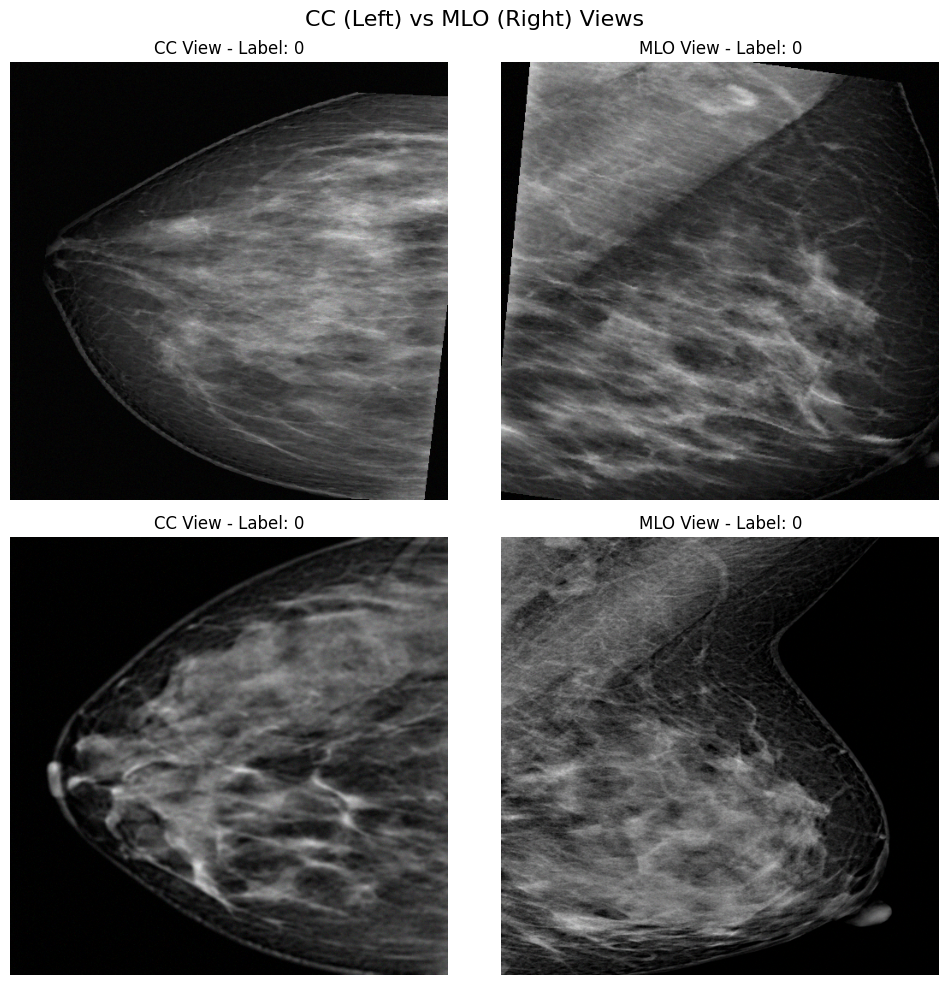


Displaying sample images from val loader:


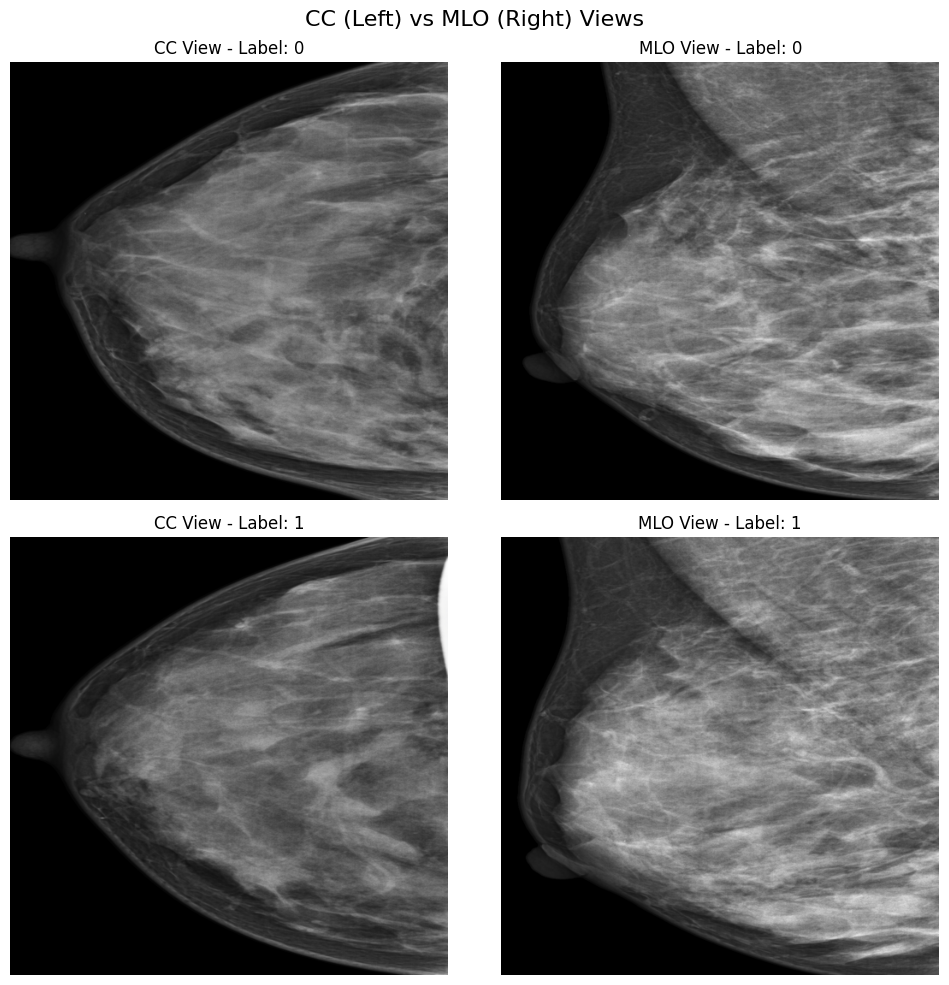

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def denormalize_image(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Convert a normalized tensor back to a numpy image for display"""
    tensor = tensor.clone().cpu()
    tensor = tensor.permute(1, 2, 0).numpy()
    tensor = tensor * std + mean
    tensor = np.clip(tensor, 0, 1)
    return tensor

def show_batch_images(batch, num_images=2):
    """Display CC and MLO images from a batch (DataLoader returns dict)"""
    cc_images = batch['cc']
    mlo_images = batch['mlo']
    labels = batch['label']

    num_images = min(num_images, len(labels))
    fig, axes = plt.subplots(num_images, 2, figsize=(10, 5 * num_images))
    fig.suptitle('CC (Left) vs MLO (Right) Views', fontsize=16)

    # Handle case where num_images == 1
    if num_images == 1:
        axes = np.expand_dims(axes, 0)

    for i in range(num_images):
        cc_img = denormalize_image(cc_images[i])
        mlo_img = denormalize_image(mlo_images[i])

        axes[i, 0].imshow(cc_img)
        axes[i, 0].set_title(f'CC View - Label: {labels[i].item()}')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mlo_img)
        axes[i, 1].set_title(f'MLO View - Label: {labels[i].item()}')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()


# ---- Display Example Batches ----
print("\nDisplaying sample images from train loader:")
for batch in train_loader:
    show_batch_images(batch)
    break

print("\nDisplaying sample images from val loader:")
for batch in val_loader:
    show_batch_images(batch)
    break


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=3.0, reduction='mean'):
        super().__init__()
        self.alpha = torch.tensor([1 - alpha, alpha])  # [weight_class_0, weight_class_1]
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)  # Model's predicted probability for true class
        
        # Get per-class alpha weights
        alpha = self.alpha.to(inputs.device)[targets]  
        
        # Focal loss calculation (penalizes class 1 more)
        focal_loss = alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

criterion = FocalLoss(
    alpha=0.6,
    gamma=3.0,    
    reduction='mean'
)

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torchvision.models.feature_extraction import create_feature_extractor

class MammoDualViewModel(nn.Module):
    """
    Dual-view mammography model.
    Compatible with ResNet, DenseNet, and EfficientNet backbones.
    Each view (CC, MLO) is processed by its own backbone.
    Features are adaptively fused via MLO weighting and classified jointly.
    """
    def __init__(self, backbone_class, backbone_weights=None, num_classes=2, feature_dim=512, dropout=0.3):
        super().__init__()

        # Instantiate both view-specific backbones
        self.cc_backbone = backbone_class(weights=backbone_weights)
        self.mlo_backbone = backbone_class(weights=backbone_weights)

        # ---- Identify feature extractor & feature dimension ----
        self.cc_extractor, num_features = self._get_feature_extractor(self.cc_backbone)
        self.mlo_extractor, _ = self._get_feature_extractor(self.mlo_backbone)

        # ---- Projection layers (map backbone features → latent space) ----
        self.cc_proj = nn.Sequential(
            nn.Linear(num_features, feature_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )

        self.mlo_proj = nn.Sequential(
            nn.Linear(num_features, feature_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )

        # ---- Adaptive weighting for MLO branch ----
        self.weight_net = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

        # ---- MLO branch processing ----
        self.mlo_processor = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True)
        )

        # ---- Final classification head ----
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim + 256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    # ==============================================================
    # Helper function to handle different backbone architectures
    # ==============================================================    
    def _get_feature_extractor(self, model):
        """
        Returns a model stripped of its classification head and its output feature size.
        Supports EfficientNet, ResNet, DenseNet.
        """
        # ---------- EfficientNet ----------
        if hasattr(model, "classifier") and hasattr(model.classifier, "in_features"):
            num_features = model.classifier.in_features
            model.classifier = nn.Identity()
            return model, num_features

        # ---------- EfficientNet (Sequential classifier) ----------
        if hasattr(model, "classifier") and isinstance(model.classifier, nn.Sequential):
            # Newer torchvision EfficientNets use classifier[1]
            num_features = model.classifier[-1].in_features
            model.classifier = nn.Identity()
            return model, num_features

        # ---------- ResNet ----------
        if hasattr(model, "fc"):
            num_features = model.fc.in_features
            model.fc = nn.Identity()
            return model, num_features

        # ---------- DenseNet ----------
        if hasattr(model, "classifier") and hasattr(model, "features"):
            num_features = model.classifier.in_features
            model.classifier = nn.Identity()
            return model, num_features

        # ---------- Fallback ----------
        print("[Warning] Unknown architecture: defaulting to 1000 features.")
        return model, 1000

    # ==============================================================
    # Forward pass
    # ==============================================================    
    def forward(self, cc, mlo):
        # Extract features
        cc_feat = self.cc_extractor(cc)
        mlo_feat = self.mlo_extractor(mlo)

        # Global average pool if needed
        if cc_feat.dim() == 4:
            cc_feat = cc_feat.mean([-2, -1])
        if mlo_feat.dim() == 4:
            mlo_feat = mlo_feat.mean([-2, -1])

        # Project to latent space
        cc_feat = self.cc_proj(cc_feat)
        mlo_feat = self.mlo_proj(mlo_feat)

        # Adaptive weighting of MLO features
        mlo_weight = self.weight_net(mlo_feat)           # shape [B, 1]
        mlo_weighted = mlo_feat * mlo_weight             # scaled features

        # Process MLO branch
        mlo_processed = self.mlo_processor(mlo_weighted)

        # Concatenate CC + MLO representations
        combined = torch.cat([cc_feat, mlo_processed], dim=1)

        # Classification
        logits = self.classifier(combined)
        return logits

In [19]:
models_config = [
    # {
    #     'name': 'efficientnet_b3',
    #     'class': models.efficientnet_b3,
    #     'weights': models.EfficientNet_B3_Weights.DEFAULT
    # },
    {
        'name': 'convnext_base',
        'class': models.convnext_base,
        'weights': models.ConvNeXt_Base_Weights.DEFAULT
    },
]

In [20]:
class AsymmetricFocalLoss(nn.Module):
    def __init__(
        self,
        gamma_neg: float = 1.0,  # benign
        gamma_pos: float = 3.0,  # malignant
        alpha: float = 0.75,     # weight for malignant
        eps: float = 1e-8
    ):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.alpha = alpha
        self.eps = eps

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce_loss).clamp(min=self.eps, max=1.0)
        gamma = torch.where(targets == 1, self.gamma_pos, self.gamma_neg)
        alpha_t = torch.where(targets == 1, self.alpha, 1.0 - self.alpha)
        loss = alpha_t * (1.0 - pt) ** gamma * ce_loss
        return loss.mean()
        

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from torch.optim import AdamW
import time
import os
import gc
import numpy as np
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def save_results(report, cm, save_path, dataset_name):
    os.makedirs(save_path, exist_ok=True)
    
    # Save classification report
    report_path = os.path.join(save_path, f"{dataset_name}_classification_report.txt")
    with open(report_path, "w") as f:
        f.write(report)
    
    # Save confusion matrix as PNG
    cm_path = os.path.join(save_path, f"{dataset_name}_confusion_matrix.png")
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(f'Confusion Matrix - {dataset_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(cm_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"Saved report and CM for {dataset_name} in {save_path}")


class EarlyStopper:
    def __init__(self, patience=10, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None

    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
            return False
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            return self.counter >= self.patience
        else:
            self.best_score = score
            self.counter = 0
            return False


def run_epoch(model, loader, criterion, optimizer=None, scaler=None, train=True):
    model.train() if train else model.eval()
    total_loss, preds_all, labels_all, probs_all = 0.0, [], [], []

    with torch.set_grad_enabled(train):
        for batch in loader:
            cc = batch['cc']
            mlo = batch['mlo']
            labels = batch['label']
            cc, mlo, labels = cc.to(device), mlo.to(device), labels.to(device)
            
            if train and scaler is not None:
                # Mixed precision training
                with torch.amp.autocast('cuda'):
                    outputs = model(cc, mlo)
                    loss = criterion(outputs, labels)
                
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                # Regular forward pass (validation/test or no scaler)
                outputs = model(cc, mlo)
                loss = criterion(outputs, labels)
                
                if train and optimizer is not None:
                    optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()

            total_loss += loss.item() * cc.size(0)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(1)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
            probs_all.extend(probs.detach().cpu().numpy())

    loss = total_loss / len(loader.dataset)
    f1 = f1_score(labels_all, preds_all, average='macro')
    f1_pos = f1_score(labels_all, preds_all, average='binary', pos_label=1)
    acc = np.mean(np.array(labels_all) == np.array(preds_all)) * 100
    report = classification_report(labels_all, preds_all, target_names=['Neg', 'Pos'])
    cm = confusion_matrix(labels_all, preds_all)
    auc = roc_auc_score(labels_all, np.array(probs_all)[:, 1]) if len(np.unique(labels_all)) > 1 else 0.5
    return loss, acc, f1, f1_pos, auc, report, cm


def train_and_evaluate(model_name, backbone, weights, train_loader, val_loader, test_loader, inbreast_loader):
    model = MammoDualViewModel(backbone, weights).to(device)
    criterion = AsymmetricFocalLoss(
        gamma_neg=1.5,   
        gamma_pos=1.0,    
        alpha=0.5     
    )
    
    optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4, min_lr=1e-6)
    stopper = EarlyStopper(patience=15)
    
    # Initialize GradScaler with new syntax
    scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

    save_dir = f"Thesis_updated_results/2_view_binary_512/{model_name}"
    os.makedirs(save_dir, exist_ok=True)
    best_model_path = os.path.join(save_dir, "best_model.pth")

    best_f1 = 0.0
    epochs = 60

    for epoch in range(epochs):
        start = time.time()

        train_loss, train_acc, train_f1, _, _, _, _ = run_epoch(
            model, train_loader, criterion, optimizer, scaler, train=True
        )
        val_loss, val_acc, val_f1, val_f1_pos, val_auc, val_report, val_cm = run_epoch(
            model, val_loader, criterion, train=False
        )

        scheduler.step(val_f1)

        print(f"\nEpoch {epoch+1}/{epochs} | LR={optimizer.param_groups[0]['lr']:.2e}")
        print(f"Train Loss: {train_loss:.4f}, F1: {train_f1:.4f}")
        print(f"Val Loss: {val_loss:.4f}, F1: {val_f1:.4f}, AUC: {val_auc:.4f}")
        print(val_report)
        print("Val CM:\n", val_cm)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), best_model_path)
            print("Saved new best model")

        if stopper(val_f1):
            print("Early stopping triggered.")
            break

    # Load best model
    model.load_state_dict(torch.load(best_model_path))

    # Final evaluation
    print("\n=== FINAL EVALUATION ===")
    for loader, name in [(test_loader, "VinDr-Test"), (inbreast_loader, "InBreast-Test")]:
        loss, acc, f1, f1_pos, auc, report, cm = run_epoch(
            model, loader, criterion, train=False
        )
        print(f"\n{model_name} | {name} Results")
        print(f"Loss: {loss:.4f}, Acc: {acc:.2f}, F1: {f1:.4f}, F1+ : {f1_pos:.4f}, AUC: {auc:.4f}")
        print(report)
        print("CM:\n", cm)

        # Save results per dataset
        dataset_folder = "vindr" if "VinDr" in name else "inbreast"
        save_results(report, cm, os.path.join(save_dir, dataset_folder), dataset_folder)

    del model
    gc.collect()
    torch.cuda.empty_cache()


for cfg in models_config:
    train_and_evaluate(
        cfg['name'], cfg['class'], cfg['weights'],
        train_loader, val_loader, test_loader, inbreast_loader
    )


Epoch 1/60 | LR=1.00e-05
Train Loss: 0.1419, F1: 0.4128
Val Loss: 0.1253, F1: 0.4691, AUC: 0.6557
              precision    recall  f1-score   support

         Neg       0.71      0.99      0.83       548
         Pos       0.78      0.06      0.11       236

    accuracy                           0.71       784
   macro avg       0.74      0.53      0.47       784
weighted avg       0.73      0.71      0.61       784

Val CM:
 [[544   4]
 [222  14]]
Saved new best model
